In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

plt.rcParams.update({'font.size': 13, 'figure.figsize': (8, 5)})

### **2(a)**

In [ ]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1.T + b1
    h = np.tanh(z1)
    z2 = h @ W2 + b2
    y_hat = sigmoid(z2)
    return y_hat, h

def backward(X, y, y_hat, h, W2):
    N = len(y)
    delta2 = (y_hat - y)
    dW2 = (h.T @ delta2) / N
    db2 = np.mean(delta2)
    delta1 = np.outer(delta2, W2) * (1 - h**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)
    return dW1, db1, dW2, db2

def binary_cross_entropy(y, yh):
    eps = 1e-12
    yh = np.clip(yh, eps, 1 - eps)
    return -np.mean(y * np.log(yh) + (1 - y) * np.log(1 - yh))

def train_network(X, y, H=4, lr=0.5, n_epochs=2000, seed=0, verbose=True, 
                  ndiv=500):
    N, D = X.shape
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((H, D)) * 0.5
    b1 = np.zeros(H)
    W2 = rng.standard_normal(H) * 0.5
    b2 = 0.0
    losses = []
    for epoch in range(n_epochs):
        y_hat, h = forward(X, W1, b1, W2, b2)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)
        dW1, db1_g, dW2, db2_g = backward(X, y, y_hat, h, W2)
        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f'  epoch {epoch:5d}  loss = {loss:.4f}  acc = {acc:.2%}')
    return W1, b1, W2, b2, losses

def plot_xor_result(W1, b1, W2, b2, losses, title=''):
    """Plot loss curve and decision boundary for XOR."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(losses, 'k-', lw=1)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training loss')
    
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    Z, _ = forward(np.c_[xx.ravel(), yy.ravel()], W1, b1, W2, b2)
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    plt.scatter([0,1], [0,1], c='tab:blue', s=200, edgecolors='k', zorder=5)
    plt.scatter([0,1], [1,0], c='tab:red', s=200, edgecolors='k', zorder=5)
    plt.set_title('Decision boundary')
    
    y_pred, _ = forward(X_xor, W1, b1, W2, b2)
    fig.suptitle(f'{title}  |  predictions: {y_pred.round(2)}', fontsize=13)
    plt.tight_layout()
    plt.show()

In [8]:
# The XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

W1_xor, b1_xor, W2_xor, b2_xor, losses_xor = train_network(
    X_xor, y_xor, H=4, lr=1.0, n_epochs=5000, seed=0, verbose=True
)

y_pred_xor, _ = forward(X_xor, W1_xor, b1_xor, W2_xor, b2_xor)
print("\nFinal XOR predictions:")
print(np.round(y_pred_xor, 3))
print("True labels:")
print(y_xor)

  epoch     0  loss = 0.6948  acc = 50.00%
  epoch   500  loss = 0.0034  acc = 100.00%
  epoch  1000  loss = 0.0014  acc = 100.00%
  epoch  1500  loss = 0.0009  acc = 100.00%
  epoch  2000  loss = 0.0006  acc = 100.00%
  epoch  2500  loss = 0.0005  acc = 100.00%
  epoch  3000  loss = 0.0004  acc = 100.00%
  epoch  3500  loss = 0.0003  acc = 100.00%
  epoch  4000  loss = 0.0003  acc = 100.00%
  epoch  4500  loss = 0.0003  acc = 100.00%

Final XOR predictions:
[0. 1. 1. 0.]
True labels:
[0. 1. 1. 0.]


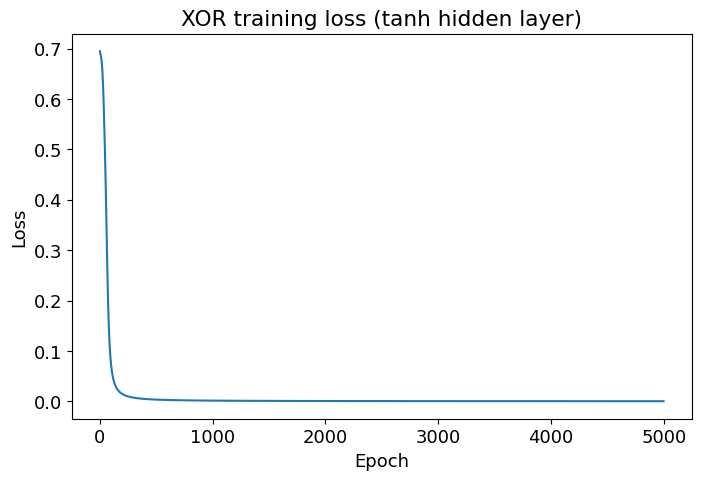

In [9]:
plt.plot(losses_xor)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR training loss (tanh hidden layer)")
plt.show()

---

### **2(b)**

In [11]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)


W1_m, b1_m, W2_m, b2_m, losses_m = train_network(
    X_tr, y_tr, H=10, lr=0.1, n_epochs=5000, seed=0, verbose=True
)

y_hat_te, _ = forward(X_te, W1_m, b1_m, W2_m, b2_m)
y_pred_te = (y_hat_te > 0.5).astype(int)
acc_tanh = np.mean(y_pred_te == y_te)

print(f"Tanh network test accuracy: {acc_tanh:.2%}")

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_tr, y_tr)
acc_lr = clf_lr.score(X_te, y_te)

print(f"Logistic regression test accuracy: {acc_lr:.2%}")

  epoch     0  loss = 0.5910  acc = 68.57%
  epoch   500  loss = 0.2849  acc = 87.43%
  epoch  1000  loss = 0.2737  acc = 87.57%
  epoch  1500  loss = 0.2301  acc = 89.14%
  epoch  2000  loss = 0.1717  acc = 92.43%
  epoch  2500  loss = 0.1359  acc = 95.29%
  epoch  3000  loss = 0.1147  acc = 96.43%
  epoch  3500  loss = 0.1008  acc = 96.86%
  epoch  4000  loss = 0.0911  acc = 97.00%
  epoch  4500  loss = 0.0841  acc = 97.14%
Tanh network test accuracy: 95.33%
Logistic regression test accuracy: 86.67%


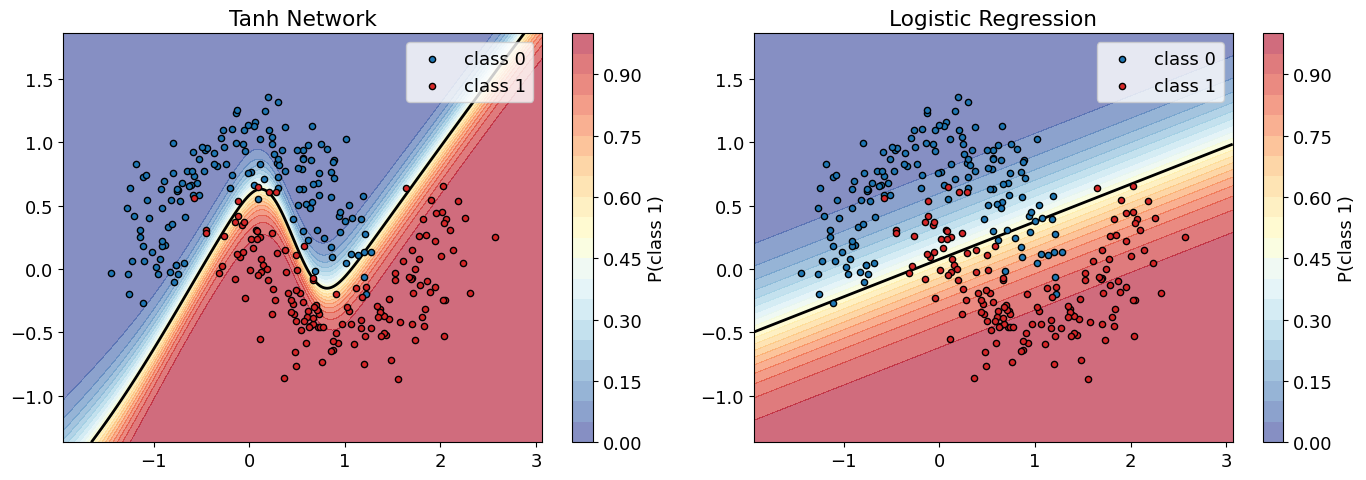

In [20]:
def plot_decision_boundary(X, y, forward_fn, clf, params, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2 = params
    probs, _ = forward_fn(grid, W1, b1, W2, b2)
    Z = probs.reshape(xx.shape)

    axes[0].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[0].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    axes[0].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[0].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[0].set_title(title1)
    axes[0].legend()
    plt.colorbar(axes[0].collections[0], ax=axes[0], label='P(class 1)')


    probs_lr = clf.predict_proba(grid)[:,1].reshape(xx.shape)

    axes[1].contourf(xx, yy, probs_lr, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, probs_lr, levels=[0.5], colors='k', linewidths=2)
    axes[1].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[1].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[1].set_title(title2)
    axes[1].legend()
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(class 1)')
    
    plt.tight_layout()
    plt.show()


plot_decision_boundary(X_te, y_te, forward, clf_lr, (W1_m, b1_m, W2_m, b2_m), "Tanh Network", "Logistic Regression")

---

### **2(C)**

In [21]:
def forward_2(X, W1, b1, W2, b2, W3, b3):
    z1 = X @ W1.T + b1
    h1 = np.tanh(z1)

    z2 = h1 @ W2.T + b2
    h2 = np.tanh(z2)

    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)

    return y_hat, h1, h2

def backward_2(X, y, y_hat, h1, h2, W2, W3):
    N = len(y)
    
    delta3 = y_hat - y
    dW3 = (h2.T @ delta3) / N
    db3 = np.mean(delta3)

    delta2 = np.outer(delta3, W3) * (1 - h2**2)
    dW2 = (delta2.T @ h1) / N
    db2 = np.mean(delta2, axis=0)

    delta1 = (delta2 @ W2) * (1 - h1**2)
    dW1 = (delta1.T @ X) / N
    db1 = np.mean(delta1, axis=0)

    return dW1, db1, dW2, db2, dW3, db3

def train_network_2(X, y, H1=10, H2=5, lr=0.1, n_epochs=5000, seed=0,
                    verbose=True, ndiv=500):
    rng = np.random.default_rng(seed)
    N, D = X.shape

    W1 = rng.standard_normal((H1, D)) * 0.5
    b1 = np.zeros(H1)

    W2 = rng.standard_normal((H2, H1)) * 0.5
    b2 = np.zeros(H2)

    W3 = rng.standard_normal(H2) * 0.5
    b3 = 0.0

    losses = []

    for epoch in range(n_epochs):
        y_hat, h1, h2 = forward_2(X, W1, b1, W2, b2, W3, b3)
        loss = binary_cross_entropy(y, y_hat)
        losses.append(loss)

        dW1, db1_g, dW2, db2_g, dW3, db3_g = backward_2(
            X, y, y_hat, h1, h2, W2, W3
        )

        W1 -= lr * dW1
        b1 -= lr * db1_g
        W2 -= lr * dW2
        b2 -= lr * db2_g
        W3 -= lr * dW3
        b3 -= lr * db3_g

        if verbose and epoch % ndiv == 0:
            acc = np.mean((y_hat > 0.5).astype(int) == y)
            print(f"epoch {epoch:5d} | loss = {loss:.4f} | acc = {acc:.2%}")

    return W1, b1, W2, b2, W3, b3, losses

In [23]:
W1_2, b1_2, W2_2, b2_2, W3_2, b3_2, losses_2 = train_network_2(
    X_tr, y_tr, H1=10, H2=5, lr=0.1, n_epochs=5000, seed=0, verbose=True
)

y_hat_te_2, _, _ = forward_2(X_te, W1_2, b1_2, W2_2, b2_2, W3_2, b3_2)
y_pred_te_2 = (y_hat_te_2 > 0.5).astype(int)
acc_tanh_2 = np.mean(y_pred_te_2 == y_te)

print(f"Two-hidden-layer network test accuracy: {acc_tanh_2:.2%}")
print(f"One-hidden-layer tanh network test accuracy: {acc_tanh:.2%}")

epoch     0 | loss = 0.9457 | acc = 33.86%
epoch   500 | loss = 0.1991 | acc = 92.29%
epoch  1000 | loss = 0.0908 | acc = 97.29%
epoch  1500 | loss = 0.0662 | acc = 98.00%
epoch  2000 | loss = 0.0579 | acc = 97.86%
epoch  2500 | loss = 0.0538 | acc = 97.71%
epoch  3000 | loss = 0.0514 | acc = 98.29%
epoch  3500 | loss = 0.0499 | acc = 98.29%
epoch  4000 | loss = 0.0487 | acc = 98.43%
epoch  4500 | loss = 0.0478 | acc = 98.43%
Two-hidden-layer network test accuracy: 96.00%
One-hidden-layer tanh network test accuracy: 95.33%


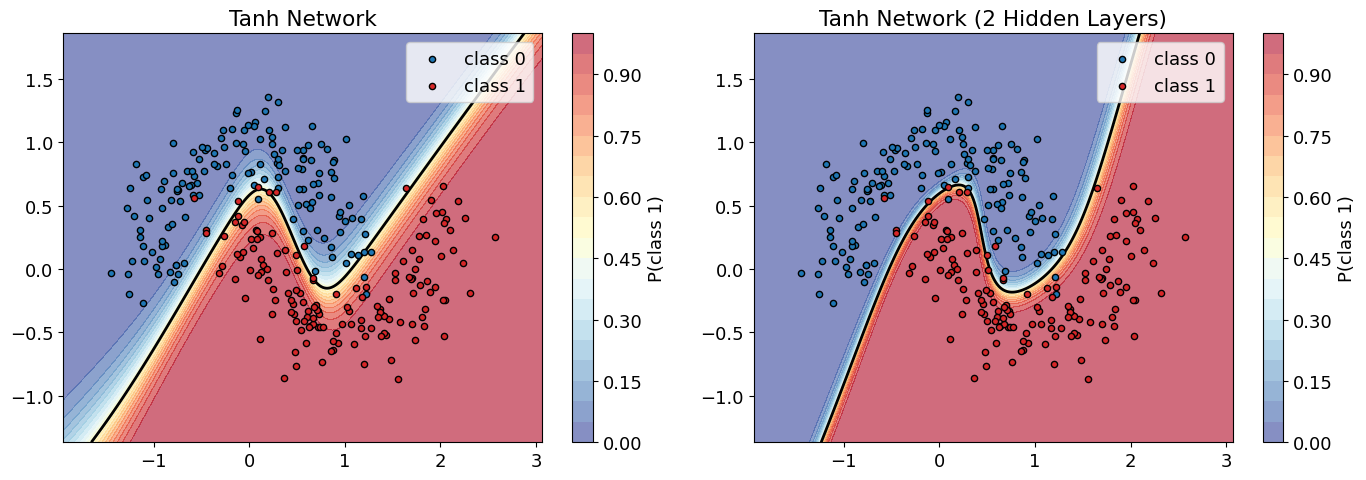

In [26]:
def plot_decision_boundary_2(X, y, forward_fn1, forward_fn2, params1, params2, title1, title2):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2 = params1
    probs, _ = forward_fn1(grid, W1, b1, W2, b2)
    Z = probs.reshape(xx.shape)

    axes[0].contourf(xx, yy, Z, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[0].contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    axes[0].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[0].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[0].set_title(title1)
    axes[0].legend()
    plt.colorbar(axes[0].collections[0], ax=axes[0], label='P(class 1)')


    W1_2, b1_2, W2_2, b2_2, W3_2, b3_2 = params2
    probs2, _, _ = forward_fn2(grid, W1_2, b1_2, W2_2, b2_2, W3_2, b3_2)
    Z2 = probs2.reshape(xx.shape)

    axes[1].contourf(xx, yy, Z2, levels=np.linspace(0, 1, 21), cmap='RdYlBu_r', alpha=0.6)
    axes[1].contour(xx, yy, Z2, levels=[0.5], colors='k', linewidths=2)
    axes[1].scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', s=20, edgecolors='k', zorder=5, label='class 0')
    axes[1].scatter(X[y==1, 0], X[y==1, 1], c='tab:red', s=20, edgecolors='k', zorder=5, label='class 1')
    axes[1].set_title(title2)
    axes[1].legend()
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='P(class 1)')
    
    plt.tight_layout()
    plt.show()


plot_decision_boundary_2(X_te, y_te, forward, forward_2, (W1_m, b1_m, W2_m, b2_m), (W1_2, b1_2, W2_2, b2_2, W3_2, b3_2), "Tanh Network", "Tanh Network (2 Hidden Layers)")

---

### **2(d)**

**What was the hardest part of adding the second layer? What errors did you encounter? Relate this experience to why frameworks like PyTorch exist.**

The hardest part was keeping track of the propagation in the backward function. With one more layer, there are one more set of weights, so it is much harder to apply the chain rule and propagate with the right order of operations. The main errors happened when doing the hardes part mentioned above. It was confusing to match the size of the matrices when doing matrix multiplication. It was also easy to mix up which layer output should be used in the next propagation. Hence, frameworks like PyTorch are useful to save time from manually coding and to reduce errors, especially for more hidden layers or more complicated structures.